# Milestone 0: Data Preparation & Exploration

This notebook covers the data preparation, cleaning, product-level splitting (to prevent leakage), and exploratory data analysis (EDA) for the `All_Beauty` category of the **Amazon Reviews 2023** dataset.

## 1. Setup, Environment Detection & Imports

In [ ]:
import sys
import os
from pathlib import Path

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab. Installing compatible datasets library (<3.0.0) and other packages...")
    !pip install "datasets>=2.16.0,<3.0.0" transformers diffusers accelerate gradio -q 2>/dev/null
    # We install datasets < 3.0.0 because datasets 3.0+ completely disabled loading scripts like Amazon-Reviews-2023.py

    os.makedirs('src', exist_ok=True)
    os.makedirs('data/processed', exist_ok=True)
    os.makedirs('data/images', exist_ok=True)
    os.makedirs('data/plots', exist_ok=True)

    # Write data.py directly to Colab disk
    data_py_code = """import os
import json
import pandas as pd
import numpy as np
import requests
from pathlib import Path
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import io
from PIL import Image
from tqdm import tqdm

def load_amazon_data(category="All_Beauty"):
    print(f"Loading reviews for {category}...")
    reviews_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_review_{category}", trust_remote_code=True)
    reviews_df = pd.DataFrame(reviews_dataset['full'])

    print(f"Loading metadata for {category}...")
    meta_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_meta_{category}", split="full", trust_remote_code=True)
    meta_df = pd.DataFrame(meta_dataset)
    return reviews_df, meta_df

def clean_data(reviews_df, meta_df):
    print("Cleaning metadata...")
    def clean_price(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (int, float)):
            return float(x)
        x_str = str(x).replace('$', '').replace(',', '').strip()
        try:
            return float(x_str)
        except ValueError:
            return np.nan
    meta_df['price_cleaned'] = meta_df['price'].apply(clean_price)
    # Process images: extract the first image URL if it is a list of dicts/strings
    def extract_image_url(images_val):
        if not images_val or pd.isna(images_val):
            return None

        def first_string(val):
            if isinstance(val, list):
                if len(val) > 0:
                    first = val[0]
                    if isinstance(first, str):
                        return first
                    elif isinstance(first, dict) and 'large' in first:
                        return first['large']
            elif isinstance(val, str):
                return val
            return None

        if isinstance(images_val, dict):
            for key in ['large', 'hi_res', 'thumb']:
                if key in images_val:
                    res = first_string(images_val[key])
                    if res:
                        return res
            return None

        if isinstance(images_val, (list, np.ndarray)):
            return first_string(list(images_val))

        return None
    meta_df['image_url'] = meta_df['images'].apply(extract_image_url)

    def clean_description(desc):
        if isinstance(desc, list):
            return " ".join([str(d) for d in desc])
        if pd.isna(desc):
            return ""
        return str(desc)
    meta_df['description_cleaned'] = meta_df['description'].apply(clean_description)

    print("Cleaning reviews...")
    reviews_df['rating'] = pd.to_numeric(reviews_df['rating'], errors='coerce')
    vote_col = 'helpful_vote' if 'helpful_vote' in reviews_df.columns else 'helpful_votes'
    if vote_col in reviews_df.columns:
        reviews_df['helpful_votes'] = pd.to_numeric(reviews_df[vote_col], errors='coerce').fillna(0).astype(int)
    else:
        reviews_df['helpful_votes'] = 0
    reviews_df['text_cleaned'] = reviews_df['text'].fillna("")
    reviews_df['title_cleaned'] = reviews_df['title'].fillna("")
    return reviews_df, meta_df

def split_by_product(reviews_df, meta_df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42):
    print("Splitting data by product...")
    prod_col = 'parent_asin' if ('parent_asin' in meta_df.columns and 'parent_asin' in reviews_df.columns) else 'asin'
    unique_products = list(set(meta_df[prod_col].unique()) & set(reviews_df[prod_col].unique()))

    train_prods, test_val_prods = train_test_split(unique_products, train_size=train_ratio, random_state=random_seed)
    val_relative_ratio = val_ratio / (val_ratio + test_ratio)
    val_prods, test_prods = train_test_split(test_val_prods, train_size=val_relative_ratio, random_state=random_seed)

    train_prods_set = set(train_prods)
    val_prods_set = set(val_prods)
    test_prods_set = set(test_prods)

    meta_train = meta_df[meta_df[prod_col].isin(train_prods_set)]
    meta_val = meta_df[meta_df[prod_col].isin(val_prods_set)]
    meta_test = meta_df[meta_df[prod_col].isin(test_prods_set)]

    reviews_train = reviews_df[reviews_df[prod_col].isin(train_prods_set)]
    reviews_val = reviews_df[reviews_df[prod_col].isin(val_prods_set)]
    reviews_test = reviews_df[reviews_df[prod_col].isin(test_prods_set)]
    return (reviews_train, meta_train), (reviews_val, meta_val), (reviews_test, meta_test)

def download_and_cache_images(meta_df, output_dir, max_images=500):
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    valid_images = meta_df[meta_df['image_url'].notna() & (meta_df['image_url'] != "")]
    if len(valid_images) > max_images:
        valid_images = valid_images.sample(n=max_images, random_state=42)

    image_paths = {}
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    id_col = 'asin' if 'asin' in meta_df.columns else ('parent_asin' if 'parent_asin' in meta_df.columns else 'asin')
    for _, row in tqdm(valid_images.iterrows(), total=len(valid_images)):
        prod_id = row[id_col]
        url = row['image_url']
        ext = Path(url).suffix if Path(url).suffix in ['.jpg', '.jpeg', '.png'] else '.jpg'
        local_file = output_path / f"{prod_id}{ext}"
        if local_file.exists():
            image_paths[prod_id] = str(local_file)
            continue
        try:
            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code == 200:
                img = Image.open(io.BytesIO(response.content))
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                img.save(local_file, "JPEG")
                image_paths[prod_id] = str(local_file)
            else:
                image_paths[prod_id] = None
        except:
            image_paths[prod_id] = None
    return image_paths
"""
    with open('src/data.py', 'w', encoding='utf-8') as f:
        f.write(data_py_code)
    sys.path.append(os.path.abspath('src'))
    processed_dir_path = 'data/processed'
    images_dir_path = 'data/images'
else:
    sys.path.append(os.path.abspath('../src'))
    processed_dir_path = '../data/processed'
    images_dir_path = '../data/images'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from PIL import Image
from data import load_amazon_data, clean_data, split_by_product, download_and_cache_images

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

Running in Google Colab. Installing compatible datasets library (<3.0.0) and other packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 6.7 MB/s eta 0:00:00


## 2. Load the Dataset
We load both the reviews and item metadata from Hugging Face.

In [ ]:
reviews_df, meta_df = load_amazon_data("All_Beauty")

Loading reviews for All_Beauty...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating full split: 0 examples [00:00, ? examples/s]

Loading metadata for All_Beauty...


Generating full split:   0%|          | 0/112590 [00:00<?, ? examples/s]

## 3. Data Cleaning
We parse the prices, clean description texts, handle list formats, and clean up rating variables.

In [ ]:
reviews_df, meta_df = clean_data(reviews_df, meta_df)

Cleaning metadata...
Cleaning reviews...


## 4. Exploratory Data Analysis (EDA)
Let's look at the basic dataset shapes and missing data counts.

In [ ]:
print(f"Total reviews: {len(reviews_df)}")
print(f"Total products in metadata: {len(meta_df)}")
print(f"Unique products with reviews: {reviews_df['parent_asin'].nunique()}")

Total reviews: 701528
Total products in metadata: 112590
Unique products with reviews: 112565


### 4.1 Rating Distribution
Let's explore if there's any rating imbalance (which is a common pitfall mentioned in the guidelines).

1.0 Stars: 102080 (14.55%)
2.0 Stars: 43034 (6.13%)
3.0 Stars: 56307 (8.03%)
4.0 Stars: 79381 (11.32%)
5.0 Stars: 420726 (59.97%)


/tmp/ipykernel_4163/521675792.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews_df, x='rating', palette="viridis")


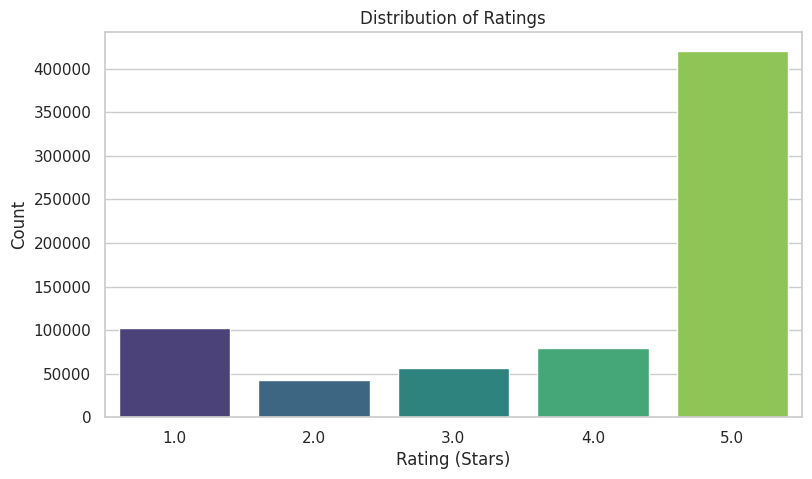

In [ ]:
rating_counts = reviews_df['rating'].value_counts().sort_index()
for rating, count in rating_counts.items():
    percentage = (count / len(reviews_df)) * 100
    print(f"{rating} Stars: {count} ({percentage:.2f}%)")

sns.countplot(data=reviews_df, x='rating', palette="viridis")
plt.title("Distribution of Ratings")
plt.xlabel("Rating (Stars)")
plt.ylabel("Count")
plt.show()

### 4.2 Price Distribution

count    17704.00000
mean        27.25573
std         50.47202
min          0.01000
25%          9.99000
50%         16.99000
75%         29.90000
max       2548.98000
Name: price_cleaned, dtype: float64


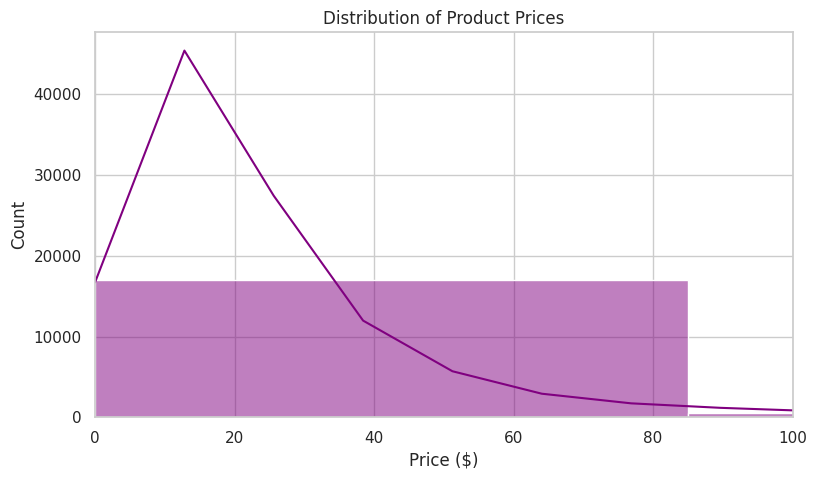

In [ ]:
prices = meta_df['price_cleaned'].dropna()
print(prices.describe())

sns.histplot(prices, bins=30, kde=True, color='purple')
plt.title("Distribution of Product Prices")
plt.xlabel("Price ($)")
plt.xlim(0, 100)
plt.show()

### 4.3 Review Length Distribution

count    701528.000000
mean         32.750720
std          45.973273
min           0.000000
25%           8.000000
50%          19.000000
75%          40.000000
max        2585.000000
Name: review_length, dtype: float64


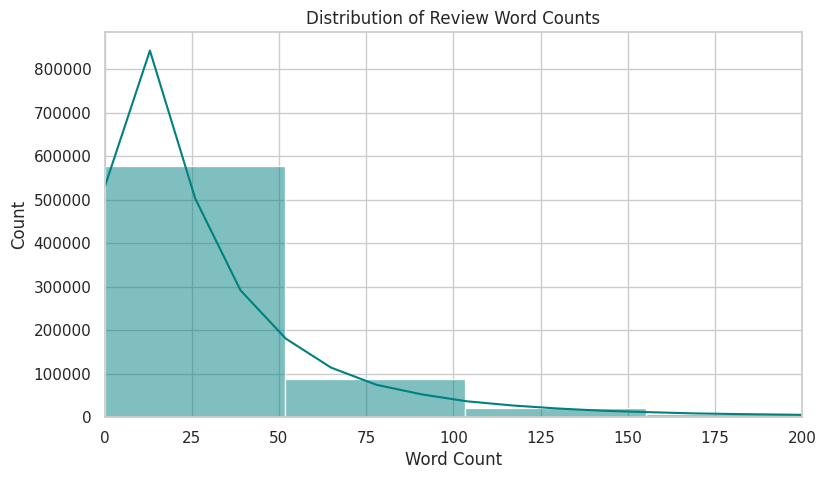

In [ ]:
reviews_df['review_length'] = reviews_df['text_cleaned'].apply(lambda x: len(str(x).split()))
lengths = reviews_df['review_length']
print(lengths.describe())

sns.histplot(lengths, bins=50, kde=True, color='teal')
plt.title("Distribution of Review Word Counts")
plt.xlabel("Word Count")
plt.xlim(0, 200)
plt.show()

### 4.4 Image Availability

In [ ]:
img_available = meta_df['image_url'].notna().sum()
print(f"Products with images: {img_available} ({img_available/len(meta_df)*100:.2f}%)")

Products with images: 112590 (100.00%)


## 5. Splitting the Dataset by Product
To prevent data leakage, we partition the dataset based on the product ID (`parent_asin`). All reviews and metadata for a given product are kept together in the same split (Train, Validation, or Test).

In [ ]:
(reviews_train, meta_train), (reviews_val, meta_val), (reviews_test, meta_test) = split_by_product(
    reviews_df, meta_df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15
)

Splitting data by product...


### 5.1 Verification of No Leakage
Let's confirm that there is zero overlap between the sets of products in our train, validation, and test splits.

In [ ]:
train_prods = set(meta_train['parent_asin'].unique())
val_prods = set(meta_val['parent_asin'].unique())
test_prods = set(meta_test['parent_asin'].unique())

assert len(train_prods.intersection(val_prods)) == 0, "Data leakage detected between train and val!"
assert len(train_prods.intersection(test_prods)) == 0, "Data leakage detected between train and test!"
assert len(val_prods.intersection(test_prods)) == 0, "Data leakage detected between val and test!"

print("Success! Product sets are completely disjoint. No data leakage detected.")

Success! Product sets are completely disjoint. No data leakage detected.


## 6. Saving Processed Splits & Downloading Image Cache

In [ ]:
# Save datasets
os.makedirs(processed_dir_path, exist_ok=True)
reviews_train.to_parquet(os.path.join(processed_dir_path, 'reviews_train.parquet'), index=False)
reviews_val.to_parquet(os.path.join(processed_dir_path, 'reviews_val.parquet'), index=False)
reviews_test.to_parquet(os.path.join(processed_dir_path, 'reviews_test.parquet'), index=False)

meta_train.to_parquet(os.path.join(processed_dir_path, 'meta_train.parquet'), index=False)
meta_val.to_parquet(os.path.join(processed_dir_path, 'meta_val.parquet'), index=False)
meta_test.to_parquet(os.path.join(processed_dir_path, 'meta_test.parquet'), index=False)

# Download sample of images
os.makedirs(images_dir_path, exist_ok=True)
image_paths = download_and_cache_images(meta_df, images_dir_path, max_images=500)

with open(os.path.join(processed_dir_path, 'image_paths_map.json'), 'w') as f:
    json.dump(image_paths, f, indent=4)

print("All datasets and image samples are successfully saved and ready for modeling!")

100%|██████████| 500/500 [00:18<00:00, 27.04it/s]

All datasets and image samples are successfully saved and ready for modeling!
